# Fundamento 2 — Preparación de datos (hands-on)

## Explicación

Reproduce, dentro de un notebook, las 6 etapas del pipeline de datos descritas en [`02-preparacion-de-datos.md`](02-preparacion-de-datos.md): ingestión → validación → EDA → limpieza → feature engineering → preprocesamiento (train/test split).

Esto es exactamente lo que hacen los scripts en `02-phase-1-local-dev-mlops/src/data_preparation/`, paso a paso y con las salidas visibles para aprender.

## Por qué es importante

Un modelo de ML nunca se entrena directamente sobre un CSV crudo: primero hay que validar que los datos cumplen un esquema esperado, entenderlos visualmente (EDA), limpiarlos, convertir texto a números (los algoritmos solo entienden números) y finalmente separar entrenamiento/prueba. Saltarse cualquiera de estos pasos suele traducirse en errores silenciosos o modelos que no generalizan.

## Mapa del notebook (para no perderse)

La idea que se repite en todo el notebook: **cada etapa lee lo que dejó la anterior, transforma, y guarda su propio CSV**. El original nunca se modifica.

| Sección | Qué pasa ahí | Archivo que deja | Variable |
|---|---|---|---|
| 0. Preparativos | Imports y carpeta de salida | — | `PROCESSED_DIR` |
| 1. Ingestión | Leer el CSV original | `raw_ingested.csv` | `df_raw` |
| 2. Validación | Comprobar tipos y valores con Pandera | `validated.csv` | `df_validated` |
| 3. EDA | Mirar los datos con gráficos | `eda.csv` | (mismos datos) |
| 4. Limpieza | Duplicados y valores faltantes | `cleaned.csv` | `df_cleaned` |
| 5. Feature engineering | Texto → números + features nuevas | `featured.csv` | `df_featured` |
| 6. Preprocesamiento | Partir 80/20 | `train.csv`, `test.csv` | `train_df`, `test_df` |

```text
employee_attrition.csv
   └─▶ raw_ingested → validated → eda → cleaned → featured → train.csv + test.csv
```

> **Cómo no perderse:** cuando no sepas dónde estás, mira **qué DataFrame se está usando**. El sufijo del nombre (`_raw`, `_validated`, `_cleaned`, `_featured`) te dice exactamente por cuántas etapas ha pasado ya el dato.

## Librerías que usamos

| Librería | Para qué la usamos aquí |
|---|---|
| `pathlib.Path` (estándar de Python) | Construir rutas de archivo de forma segura y multiplataforma |
| `numpy` | Operaciones numéricas de bajo nivel (usada internamente por pandas/sklearn) |
| `pandas` | Cargar, transformar y guardar los datos tabulares en cada etapa |
| `matplotlib.pyplot` | Motor base de gráficos (tamaño de figura, títulos, ejes) |
| `seaborn` | Gráficos estadísticos de más alto nivel sobre matplotlib (histogramas, boxplots, heatmaps) |
| `pandera` | Validar el esquema del dataset (columnas, tipos, valores permitidos) |
| `sklearn.model_selection.train_test_split` | Dividir el dataset en conjunto de entrenamiento y de prueba |

## Comandos / funciones clave de este notebook

| Comando | Qué hace |
|---|---|
| `pa.DataFrameSchema({...})` | Define el esquema esperado: columnas, tipos y valores válidos |
| `schema(df, lazy=True)` | Valida `df` contra el esquema; con `lazy=True` acumula **todos** los errores antes de fallar |
| `df.describe(include="all")` | Estadísticas resumen (media, min, max, conteos) de todas las columnas |
| `sns.histplot(...)` | Histograma de una variable numérica, con curva de densidad opcional (`kde=True`) |
| `sns.countplot(...)` | Conteo de ocurrencias de una variable categórica |
| `sns.boxplot(...)` | Distribución (mediana, cuartiles, outliers) de una variable numérica por categoría |
| `sns.heatmap(...)` | Matriz de correlación como mapa de calor |
| `df.duplicated().sum()` | Cuenta cuántas filas están duplicadas |
| `df.isnull().sum()` | Cuenta valores faltantes (`NaN`) por columna |
| `df["col"].map({...})` | Reemplaza cada valor de una columna según un diccionario (encoding) |
| `pd.cut(...)` | Agrupa valores numéricos continuos en rangos (bins) discretos |
| `train_test_split(...)` | Divide `X`/`y` en conjuntos de entrenamiento y prueba, con `stratify` para mantener el balance de clases |

Guía de referencia: [`02-preparacion-de-datos.md`](02-preparacion-de-datos.md)


## 0. Preparativos: librerías y carpeta de salida

Esta celda no transforma datos, solo deja el entorno listo:

1. **Importa las librerías** de las cuatro familias que se usan aquí: manipulación de datos (`pandas`, `numpy`), gráficos (`matplotlib`, `seaborn`), validación (`pandera`) y machine learning (`train_test_split` de scikit-learn).
2. **`%matplotlib inline`**: un "comando mágico" de Jupyter (empieza por `%`, no es Python normal) que hace que los gráficos aparezcan bajo cada celda en vez de en una ventana aparte.
3. **`pd.set_option("display.max_columns", None)`**: muestra todas las columnas al imprimir un DataFrame ancho, en lugar de recortarlas con `...`.
4. **`PROCESSED_DIR`**: la carpeta donde cada etapa irá dejando su CSV intermedio. `mkdir(parents=True, exist_ok=True)` la crea si no existe y no falla si ya está, para poder reejecutar el notebook sin errores.

**Qué mirar en la salida:** nada, no imprime. Si falla con `ModuleNotFoundError`, el kernel seleccionado no es el `.venv` de esta carpeta.


In [1]:
from pathlib import Path  # rutas de archivo multiplataforma
import numpy as np  # operaciones numéricas (soporte interno de pandas/sklearn)
import pandas as pd  # carga y manipulación de datos tabulares
import matplotlib.pyplot as plt  # motor de gráficos (figuras, ejes, títulos)
import seaborn as sns  # gráficos estadísticos de alto nivel sobre matplotlib
import pandera.pandas as pa  # validación de esquema de DataFrames
from pandera import Column, Check  # tipos de columna y reglas de validación de Pandera
from sklearn.model_selection import train_test_split  # división train/test

%matplotlib inline
# muestra los gráficos directamente debajo de cada celda, en vez de en una ventana aparte
pd.set_option("display.max_columns", None)  # evita que pandas oculte columnas al imprimir un DataFrame ancho

# Carpeta donde se van guardando los CSV intermedios de cada etapa del pipeline
PROCESSED_DIR = Path("../02-phase-1-local-dev-mlops/datasets/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)  # la crea (y las carpetas intermedias) si aún no existe

## 1. Ingestión

Cargar el CSV original y confirmar que se leyó correctamente (misma lógica que `01_ingestion.py`).

Es la etapa más simple, pero tiene una regla importante: **a partir de aquí, nadie vuelve a tocar el archivo original**. Se guarda una copia (`raw_ingested.csv`) y todas las etapas siguientes trabajan sobre las copias. Así, si algo sale mal, siempre se puede reproducir el pipeline desde cero.

Qué hace la celda:

1. Define la ruta al CSV original y lo carga con `pd.read_csv()` → `df_raw`.
2. Imprime `df_raw.shape`, la tupla `(filas, columnas)`.
3. Guarda la copia en `datasets/processed/raw_ingested.csv` con `index=False` (para no añadir una columna extra con el número de fila).
4. Muestra `head()` como comprobación visual.

**Qué mirar en la salida:** el `shape` (¿tiene el número de filas y columnas que esperabas?) y que las primeras filas se vean bien formadas. Si `shape` da algo como `(N, 1)`, el CSV se leyó con el separador equivocado.


In [4]:
raw_path = Path("../02-phase-1-local-dev-mlops/datasets/employee_attrition.csv")  # ruta al CSV original del proyecto
df_raw = pd.read_csv(raw_path)  # carga el CSV completo como DataFrame

print(f"Shape: {df_raw.shape}")  # (filas, columnas) recién cargadas
df_raw.to_csv(PROCESSED_DIR / "raw_ingested.csv", index=False)  # guarda una copia "ingerida", sin la columna de índice de pandas
df_raw.head()  # primeras 5 filas para inspección visual

Shape: (74498, 25)


,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,Education Level,Marital Status,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition,dataset_type
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,No,22,Associate Degree,Married,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed,train
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,No,21,Master’s Degree,Divorced,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed,train
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,No,11,Bachelor’s Degree,Married,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed,train
3,65791,36,Female,7,Education,3989,Good,High,High,1,No,27,High School,Single,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed,train
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,Yes,71,High School,Divorced,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed,train


## 2. Validación de esquema (Pandera)

Un **esquema** es un contrato: dice qué columnas deben existir, de qué tipo, y qué valores son aceptables. Pandera lo comprueba fila por fila y, si algo no cumple, avisa con un error detallado en vez de dejar pasar datos corruptos (misma lógica que `02_validation.py`).

> Piénsalo como los **tests unitarios del dataset**. Un error de datos que no se detecta aquí no rompe nada de inmediato: simplemente produce un modelo peor, y eso es mucho más difícil de diagnosticar semanas después.

**Cómo se lee cada línea del esquema:**

```python
"Age": Column(int, Check.ge(18), nullable=False)
#        │      │                  └ no se admiten valores vacíos
#        │      └ regla: greater or equal (>=) a 18
#        └ tipo de dato esperado
```

| Elemento | Qué exige |
|---|---|
| `Check.ge(n)` | Valor mayor o igual que `n` (útil para edades, años, ingresos) |
| `Check.isin([...])` | El valor debe ser uno de la lista (categorías cerradas como `Stayed`/`Left`) |
| `unique=True` | Sin repeticiones (se usa en `Employee ID`) |
| `nullable=False` | No se admiten valores vacíos |

**Dos parámetros globales del esquema:**

- **`strict=False`**: se permiten columnas adicionales que no estén listadas. Con `True`, cualquier columna nueva sería un error.
- **`coerce=True`**: antes de validar, Pandera intenta convertir cada columna al tipo declarado (por ejemplo, el texto `"25"` a entero `25`).

**`lazy=True` en la validación** hace que se acumulen **todos** los fallos y se reporten juntos, en vez de detenerse en el primero. Mucho más útil para arreglar un dataset de una sola pasada.

**Qué mirar en la salida:** el mensaje `Data validation successful.`. Si aparecieran errores, se imprimiría `e.failure_cases`: una tabla con la columna, la regla incumplida y el valor concreto que la rompió.

> Nota: en este notebook, si la validación falla se continúa con los datos sin validar (`df_validated = df_raw`) solo para que puedas completar el recorrido didáctico. **En un pipeline real esto debe abortar la ejecución**, no seguir adelante.


In [6]:
# Definimos el esquema esperado: cada columna, su tipo de dato, y qué valores/rangos son válidos.
# Si el CSV llega con un valor fuera de estas reglas, Pandera lo reportará como error en vez de dejarlo pasar.
employee_schema = pa.DataFrameSchema(
    {
        "Employee ID": Column(int, Check.ge(1), unique=True, nullable=False),  # entero >= 1, sin duplicados, sin nulos
        "Attrition": Column(str, Check.isin(["Stayed", "Left"]), nullable=False),  # solo estos dos valores de texto
        "Age": Column(int, Check.ge(18), nullable=False),  # edad mínima legal de 18 años
        "Gender": Column(str, Check.isin(["Male", "Female"]), nullable=False),
        "Years at Company": Column(int, Check.ge(0), nullable=False),  # no puede ser negativo
        "Job Role": Column(str, nullable=False),  # texto libre, solo se exige que no sea nulo
        "Monthly Income": Column(int, Check.ge(0), nullable=False),  # ingreso no puede ser negativo
        "Job Level": Column(str, Check.isin(["Entry", "Mid", "Senior", "Executive"]), nullable=False),
        "Work-Life Balance": Column(str, Check.isin(["Poor", "Fair", "Good", "Excellent"]), nullable=False),
        "Job Satisfaction": Column(str, Check.isin(["Low", "Medium", "High", "Very High"]), nullable=False),
        "Performance Rating": Column(str, Check.isin(["Low", "Below Average", "Average", "High"]), nullable=False),
        "Number of Promotions": Column(int, Check.ge(0), nullable=False),
        "Company Size": Column(str, Check.isin(["Small", "Medium", "Large"]), nullable=False),
        "Company Tenure": Column(int, Check.ge(0), nullable=False),
        "Remote Work": Column(str, Check.isin(["Yes", "No"]), nullable=False),
        "Leadership Opportunities": Column(str, Check.isin(["Yes", "No"]), nullable=False),
        "Innovation Opportunities": Column(str, Check.isin(["Yes", "No"]), nullable=False),
        "Company Reputation": Column(str, Check.isin(["Poor", "Fair", "Good", "Excellent"]), nullable=False),
        "Employee Recognition": Column(str, Check.isin(["Low", "Medium", "High", "Very High"]), nullable=False),
    },
    strict=False,  # permite columnas adicionales no listadas aquí, sin que eso sea un error
    coerce=True,  # intenta convertir cada columna al tipo declarado antes de validar (ej. texto "25" -> int 25)
)

try:
    df_validated = employee_schema(df_raw, lazy=True)  # valida TODO el DataFrame; lazy=True acumula todos los errores antes de fallar
    print("Data validation successful.")
except pa.errors.SchemaErrors as e:
    print("Data validation errors found:")
    print(e.failure_cases)  # tabla detallada: qué columna, qué regla y qué valor concreto falló
    df_validated = df_raw  # en este notebook seguimos con los datos sin validar solo para poder continuar el recorrido

df_validated.to_csv(PROCESSED_DIR / "validated.csv", index=False)  # guarda el resultado de esta etapa para la siguiente

Data validation successful.


### Ejercicio: romper el esquema a propósito

La mejor forma de entender para qué sirve la validación es verla fallar. Aquí ponemos `Age = 5` en la primera fila (viola `Check.ge(18)`) y volvemos a validar.

Detalles del código:

- **`df_raw.copy()`**: se trabaja sobre una copia (`df_broken`) para no dañar el DataFrame real que se sigue usando después.
- **`.loc[0, "Age"] = 5`**: `.loc` accede por etiqueta → fila 0, columna `Age`.
- El `try/except` captura `SchemaErrors` y muestra las columnas más útiles del reporte: qué columna falló, qué regla incumplió y con qué valor.

**Qué mirar en la salida:** el mensaje "Falló la validación, como se esperaba" y una tabla señalando `Age`, la regla `greater_than_or_equal_to(18)` y el valor `5`. Fíjate en lo concreto que es el mensaje: eso es lo que permite arreglar el dato en minutos en vez de horas.

**Para practicar:** prueba otras roturas y observa cómo cambia el reporte.

| Rotura | Regla que incumple |
|---|---|
| `df_broken.loc[0, "Attrition"] = "Maybe"` | `Check.isin(["Stayed", "Left"])` |
| `df_broken.loc[0, "Monthly Income"] = -100` | `Check.ge(0)` |
| `df_broken.loc[1, "Employee ID"] = df_broken.loc[0, "Employee ID"]` | `unique=True` |


In [8]:
df_broken = df_raw.copy()  # copia para no dañar df_raw, que seguimos usando en el resto del notebook
df_broken.loc[0, "Age"] = 5  # menor al mínimo permitido (Check.ge(18)) — provocamos el error a propósito

try:
    employee_schema(df_broken, lazy=True)  # vuelve a validar, ahora con el dato inválido
except pa.errors.SchemaErrors as e:
    print("Falló la validación, como se esperaba:")
    print(e.failure_cases[["column", "check", "failure_case"]].head())  # columna, regla incumplida y valor que la rompió

Falló la validación, como se esperaba:
  column                         check  failure_case
0    Age  greater_than_or_equal_to(18)             5


## 3. Análisis Exploratorio de Datos (EDA)

Aquí es donde un Data Scientist "conoce" los datos antes de decidir qué features construir (misma lógica que `03_eda.py`). **No es relleno**: cada gráfico de esta sección justifica una decisión concreta de las etapas 4, 5 y 6.

Vienen cinco celdas, cada una respondiendo una pregunta distinta:

| Celda | Pregunta | Decisión que influye |
|---|---|---|
| `describe()` | ¿Qué rangos y valores tiene cada columna? | Qué reglas poner en el esquema, qué escalar |
| Histograma de edad | ¿Cómo se reparten las edades? | Cómo agrupar la edad en rangos (`AgeGroup`) |
| Conteo de `Attrition` | ¿Está balanceado el target? | `class_weight` y `stratify` |
| Boxplot ingreso/nivel | ¿El ingreso sube con el nivel de puesto? | Si ambas columnas dicen lo mismo |
| Heatmap de correlación | ¿Hay columnas que se repiten entre sí? | Qué columnas combinar o descartar |

**Empezamos con `describe(include="all").T`:**

- `describe()` da estadísticas resumen por columna: para las numéricas, media, desviación, mínimo, máximo y cuartiles; para las de texto, cuántos valores únicos hay y cuál es el más frecuente.
- `include="all"` fuerza a incluir **también** las columnas de texto (por defecto solo saca las numéricas).
- `.T` transpone la tabla: así cada columna del dataset aparece como una fila, que es mucho más cómodo de leer cuando hay muchas columnas.

**Qué mirar en la salida:** valores mínimos y máximos que no tengan sentido (edades imposibles, ingresos negativos), y columnas de texto con más categorías de las esperadas (a menudo delatan erratas del tipo `"Yes"` vs `"yes"`).


In [9]:
df_validated.describe(include="all").T  # estadísticas resumen de TODAS las columnas (numéricas y de texto); .T transpone para leerlas como filas

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Employee ID,74498.0,NaN,NaN,NaN,37249.5,21505.864514,1.0,18625.25,37249.5,55873.75,74498.0
Age,74498.0,NaN,NaN,NaN,38.529746,12.083456,18.0,28.0,39.0,49.0,59.0
Gender,74498,2,Male,40826,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Years at Company,74498.0,NaN,NaN,NaN,15.721603,11.223744,1.0,7.0,13.0,23.0,51.0
Job Role,74498,5,Technology,19322,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Monthly Income,74498.0,NaN,NaN,NaN,7299.379514,2152.508566,1226.0,5652.0,7348.0,8876.0,16149.0
Work-Life Balance,74498,4,Good,28158,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job Satisfaction,74498,4,High,37245,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Performance Rating,74498,4,Average,44719,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number of Promotions,74498.0,NaN,NaN,NaN,0.832935,0.995289,0.0,0.0,1.0,2.0,4.0


### 3a. Distribución de edad (histograma)

Un **histograma** parte el rango de edades en tramos (`bins=30`) y dibuja una barra con cuántos empleados caen en cada tramo. La línea suave superpuesta (`kde=True`) es una estimación de densidad: la misma forma, pero continua, para ver la tendencia sin el ruido de las barras.

**Qué mirar en la salida:** dónde se concentra la plantilla (¿es una empresa joven?), si hay una sola "joroba" o varias, y si aparecen valores raros en los extremos. Esta forma es la que justifica los cortes de `AgeGroup` que se usan en la etapa 5: agrupar por tramos con sentido en lugar de tratar la edad como un número continuo.


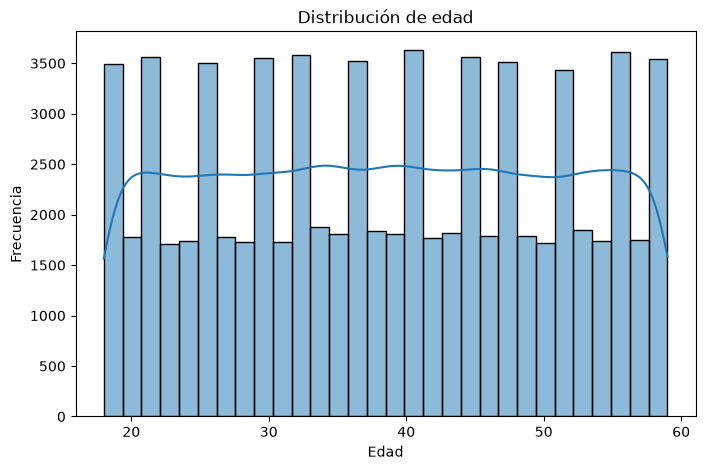

In [8]:
plt.figure(figsize=(8, 5))  # crea una figura nueva de 8x5 pulgadas
sns.histplot(df_validated["Age"], bins=30, kde=True)  # histograma de 30 barras + curva de densidad (kde) superpuesta
plt.title("Distribución de edad")  # título del gráfico
plt.xlabel("Edad")  # etiqueta del eje X
plt.ylabel("Frecuencia")  # etiqueta del eje Y
plt.show()  # renderiza el gráfico en la salida de la celda

### 3b. Balance de clases (conteo de `Attrition`)

`countplot` cuenta cuántas filas hay de cada valor del target: cuántos `Stayed` y cuántos `Left`. Debajo, la misma información en porcentaje exacto, que es lo que se suele llevar al informe.

**Qué mirar en la salida:** la diferencia de altura entre las dos barras. Cuanto más desiguales, más importa el **desbalance de clases**, y eso condiciona tres decisiones posteriores:

1. `stratify=y` al partir train/test (etapa 6) → ambas particiones conservan la misma proporción.
2. `class_weight="balanced"` al entrenar (Fundamento 3) → equivocarse con la clase minoritaria "duele" más.
3. Medir con **recall** en lugar de accuracy (Fundamento 3) → si el 80% se queda, decir siempre "se queda" da 80% de accuracy y cero utilidad.


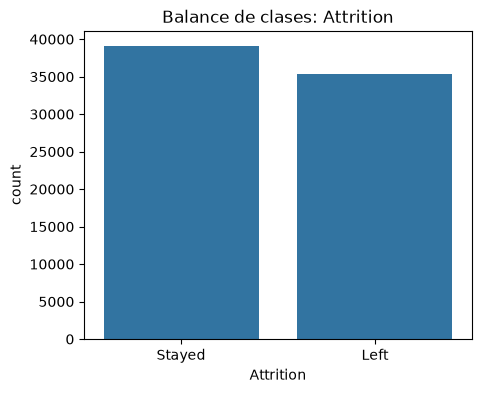

Attrition
Stayed    52.52
Left      47.48
Name: proportion, dtype: float64

In [10]:
plt.figure(figsize=(5, 4))  # figura más pequeña, hay pocas categorías que mostrar
sns.countplot(x="Attrition", data=df_validated)  # cuenta cuántas filas hay de cada valor ("Stayed"/"Left")
plt.title("Balance de clases: Attrition")
plt.show()

df_validated["Attrition"].value_counts(normalize=True).mul(100).round(2)  # mismo dato pero como % exacto, para el reporte

### 3c. Ingreso por nivel de puesto (boxplot)

Un **boxplot** ("diagrama de caja") resume la distribución de una variable numérica para cada categoría. Cómo se lee cada caja:

| Elemento | Qué representa |
|---|---|
| Línea central | La **mediana**: la mitad gana más, la mitad gana menos |
| Bordes de la caja | Cuartiles 1 y 3: dentro está el 50% central de la gente |
| "Bigotes" | El rango habitual de valores |
| Puntos sueltos | **Outliers**: casos atípicos, muy por encima o por debajo |

**Qué mirar en la salida:** que las cajas suban al avanzar de `Entry` a `Executive` (lo esperable) y si hay solapamiento fuerte entre niveles. Muchos outliers en un nivel pueden indicar un problema de datos o roles muy heterogéneos agrupados bajo la misma etiqueta.


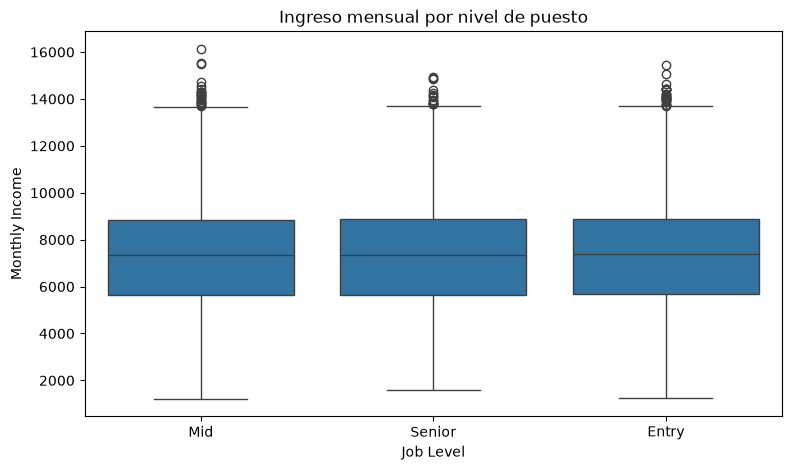

In [11]:
plt.figure(figsize=(9, 5))
sns.boxplot(x="Job Level", y="Monthly Income", data=df_validated)  # mediana, cuartiles y outliers de ingreso por nivel de puesto
plt.title("Ingreso mensual por nivel de puesto")
plt.show()

### 3d. Correlación entre columnas numéricas (heatmap)

La **correlación** mide si dos columnas se mueven juntas, en una escala de -1 a 1:

| Valor | Significado |
|---|---|
| Cerca de **1** | Suben juntas (a más de una, más de la otra) |
| Cerca de **-1** | Se mueven al revés (a más de una, menos de la otra) |
| Cerca de **0** | No hay relación lineal entre ellas |

`select_dtypes(include=["int64", "float64"])` se queda solo con las columnas numéricas (la correlación no está definida para texto), `.corr()` calcula la matriz y `sns.heatmap(..., annot=True)` la pinta con el número dentro de cada casilla.

**Qué mirar en la salida:** la diagonal siempre vale 1 (cada columna consigo misma, se ignora). Lo interesante son las casillas de color intenso fuera de la diagonal: indican **columnas redundantes**, que dicen casi lo mismo. Eso es lo que justifica que en la etapa 5 se fusionen varias columnas de satisfacción en una sola (`OverallSatisfaction`).

> Recordatorio importante: **correlación no es causalidad**. Que dos columnas se muevan juntas no significa que una provoque la otra.

Esta celda cierra el EDA guardando `eda.csv`, la entrada de la etapa de limpieza.


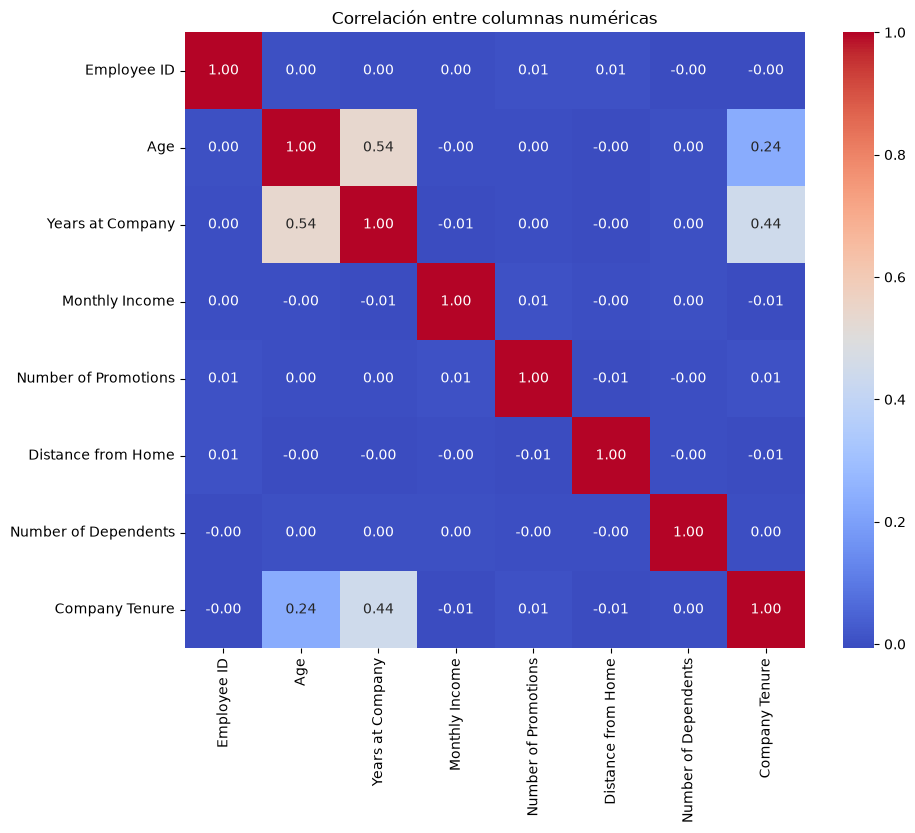

In [12]:
plt.figure(figsize=(10, 8))
corr = df_validated.select_dtypes(include=["int64", "float64"]).corr()  # matriz de correlación solo entre columnas numéricas
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")  # annot muestra el valor numérico en cada celda, con 2 decimales
plt.title("Correlación entre columnas numéricas")
plt.show()

df_validated.to_csv(PROCESSED_DIR / "eda.csv", index=False)  # guarda el resultado de esta etapa (EDA) para la siguiente (limpieza)

## 4. Limpieza

Se reportan duplicados y valores faltantes (misma lógica que `04_cleaning.py`; este dataset ya llega limpio, así que no hay nada que eliminar).

Las dos comprobaciones de la celda:

- **`df.duplicated().sum()`**: `duplicated()` marca `True` cada fila cuyo contenido completo ya apareció antes; `sum()` las cuenta. Los duplicados suelen venir de un `JOIN` mal hecho en el ETL, y son peligrosos: hacen que el modelo vea el mismo caso varias veces y le dé más peso del que merece.
- **`df.isnull().sum()`**: cuenta valores vacíos (`NaN`) columna por columna. Los algoritmos clásicos de scikit-learn **fallan** con valores faltantes, así que hay que decidir qué hacer con ellos.

**Qué hacer si aparecieran valores faltantes (aquí no ocurre):**

| Estrategia | Cuándo se usa |
|---|---|
| Eliminar la fila | Son muy pocas y no se pierde información valiosa |
| Imputar con media/mediana | Columna numérica con huecos dispersos |
| Imputar con la categoría más frecuente | Columna categórica |
| Eliminar la columna entera | Le falta un porcentaje enorme de valores |

**Qué mirar en la salida:** `Filas duplicadas: 0` y una lista de columnas con `0` faltantes en cada una. Como no hay nada que arreglar, `df_cleaned` es una copia de la etapa anterior — pero la etapa **existe igual**, porque con datos reales casi nunca sale limpia.


In [13]:
print("Filas duplicadas:", df_validated.duplicated().sum())  # cuenta filas cuyo contenido es idéntico a otra fila anterior
print("\nValores faltantes por columna:")
print(df_validated.isnull().sum())  # cuenta valores NaN/nulos por cada columna

df_cleaned = df_validated.copy()  # este dataset ya llega limpio, así que no hay nada que eliminar/imputar
df_cleaned.to_csv(PROCESSED_DIR / "cleaned.csv", index=False)  # guarda el resultado de esta etapa para feature engineering

Filas duplicadas: 0

Valores faltantes por columna:
Employee ID                 0
Age                         0
Gender                      0
Years at Company            0
Job Role                    0
Monthly Income              0
Work-Life Balance           0
Job Satisfaction            0
Performance Rating          0
Number of Promotions        0
Overtime                    0
Distance from Home          0
Education Level             0
Marital Status              0
Number of Dependents        0
Job Level                   0
Company Size                0
Company Tenure              0
Remote Work                 0
Leadership Opportunities    0
Innovation Opportunities    0
Company Reputation          0
Employee Recognition        0
Attrition                   0
dataset_type                0
dtype: int64


## 5. Feature Engineering

Los algoritmos clásicos de ML solo entienden números. Aquí convertimos cada columna de texto a un número (*encoding*) y construimos features derivadas (misma lógica que `05_feature_engg.py`).

Es la celda más larga del notebook, pero no es complicada: son **10 pasos independientes**, cada uno numerado en el código. Esta tabla es el índice para seguirlos:

| Paso | Qué hace | Ejemplo |
|---|---|---|
| 1 | Codifica el **target** | `Stayed`/`Left` → `0`/`1` |
| 2 | **Binario**: columnas de Sí/No | `Yes`/`No` → `1`/`0` |
| 3 | **Ordinal**: categorías con orden natural | `Poor/Fair/Good/Excellent` → `1/2/3/4` |
| 4 | **Agrega** 3 columnas de satisfacción en una | → `OverallSatisfaction` |
| 5 | **Agrega** liderazgo + innovación | → `Opportunities` (0, 1 o 2) |
| 6 | **Discretiza** el ingreso en rangos | ingreso anual → `0..4` |
| 7 | **Discretiza** la edad en tramos | edad → `AgeGroup` `1..5` |
| 8 | **Convierte unidades** (meses → años) | para que sean comparables |
| 9 | **Crea features de riesgo** combinando columnas | `RoleStagnationRatio`, `TenureGap`… |
| 10 | **Descarta** columnas que no son features | `Employee ID`, `Gender`, texto libre |

### Los tres tipos de codificación, en una frase

- **Binaria** (paso 2): solo hay dos valores posibles → 0 y 1.
- **Ordinal** (paso 3): las categorías tienen un orden real (`Poor` < `Fair` < `Good` < `Excellent`), así que se numeran respetándolo. El número transmite información.
- **Agregación** (pasos 4 y 5): varias columnas que dicen casi lo mismo (lo vimos en el heatmap del EDA) se resumen en una sola, más estable y con menos ruido.

### Detalles del código que suelen generar dudas

- **`.map({...})`** recorre la columna y sustituye cada valor según el diccionario. Si un valor **no está** en el diccionario, se convierte en `NaN` en silencio — por eso importa que los mapas cubran todas las categorías del esquema.
- **`"Int64"` con mayúscula** (pasos 2, 6, 7) es el entero de pandas que **admite nulos**, a diferencia del `int64` clásico de numpy. Se usa para no romper la conversión si aparece algún `NaN`.
- **`pd.cut(...)`** convierte un número continuo en tramos: `bins` marca los cortes y `labels` el número asignado a cada tramo. ¿Por qué agrupar? Porque para el negocio "estar entre 26 y 35 años" es más significativo que la edad exacta, y además reduce el ruido.
- **Features derivadas (paso 9)**: aquí es donde el Data Scientist aporta conocimiento del dominio. `RoleStagnationRatio` mide estancamiento en el rol, `TenureGap` cuánto tiempo lleva sin cambiar, y las dos `...Risk` son banderas (0/1) que codifican hipótesis de negocio: irse pronto o llevar años sin ascender. El `+1` del denominador evita la división entre cero.
- **Paso 10**: se eliminan `Employee ID` (identificador, no aporta señal), `Gender` y `Marital Status` (evitar sesgos y problemas éticos/legales), `Job Role` (texto libre) y `dataset_type` (bandera técnica, no una característica del empleado).

**Qué mirar en la salida:** el `head()` final. Todas las columnas deben ser **numéricas**, sin una sola cadena de texto. Ese es el criterio de "listo para entrenar". Compara este resultado con el `head()` de la etapa 1: es el mismo dataset, hablando otro idioma.

> En producción, estas features no se recalculan a mano en cada sitio: se guardan en un **Feature Store** (Feast, en la Fase 2), para que el entrenamiento y la API de inferencia usen exactamente las mismas fórmulas. Cuando no coinciden, se produce el *training/serving skew*: el modelo predice mal sin dar ningún error.


In [14]:
df_fe = df_cleaned.copy()  # copia de trabajo para no modificar df_cleaned

# 1. Target column: el modelo necesita el target como número, no como texto
df_fe["Attrition"] = df_fe["Attrition"].map({"Stayed": 0, "Left": 1}).astype("int")  # 0 = se quedó, 1 = se fue

# 2. Binary encoding: columnas Sí/No -> 1/0
binary_cols = ["Remote Work", "Leadership Opportunities", "Innovation Opportunities", "Overtime"]  # columnas con solo dos valores posibles
for col in binary_cols:
    df_fe[col] = df_fe[col].map({"Yes": 1, "No": 0}).astype("Int64")  # "Int64" (con mayúscula) admite nulos, a diferencia de "int64"

# 3. Ordinal encoding: categorías con un orden natural (Poor < Fair < Good < Excellent, etc.)
ordinal_maps = {
    "Work-Life Balance": {"Poor": 1, "Fair": 2, "Good": 3, "Excellent": 4},
    "Job Satisfaction": {"Low": 1, "Medium": 2, "High": 3, "Very High": 4},
    "Performance Rating": {"Low": 1, "Below Average": 2, "Average": 3, "High": 4},
    "Employee Recognition": {"Low": 1, "Medium": 2, "High": 3, "Very High": 4},
    "Company Reputation": {"Poor": 1, "Fair": 2, "Good": 3, "Excellent": 4},
    "Job Level": {"Entry": 1, "Mid": 2, "Senior": 3, "Executive": 4},
    "Company Size": {"Small": 1, "Medium": 2, "Large": 3},
    "Education Level": {"High School": 1, "Bachelor’s Degree": 2, "Master’s Degree": 3, "Associate Degree": 4, "PhD": 5},
}
for col, mapping in ordinal_maps.items():
    df_fe[col] = df_fe[col].map(mapping)  # reemplaza cada categoría de texto por su número de orden

# 4. Agregar satisfacción general (promedio de 3 métricas), para resumir 3 columnas en 1 sola feature
df_fe["OverallSatisfaction"] = ((df_fe["Work-Life Balance"] + df_fe["Job Satisfaction"] + df_fe["Employee Recognition"]) / 3).round().astype("Int64")
df_fe = df_fe.drop(columns=["Work-Life Balance", "Job Satisfaction", "Employee Recognition"])  # ya no hacen falta por separado

# 5. Combinar oportunidades de liderazgo/innovación en una sola feature (suma: 0, 1 o 2 oportunidades)
df_fe["Opportunities"] = df_fe["Leadership Opportunities"] + df_fe["Innovation Opportunities"]
df_fe = df_fe.drop(columns=["Leadership Opportunities", "Innovation Opportunities"])

# 6. Ingreso anual agrupado en rangos (bins), en vez de un número continuo
df_fe["AnnualIncome"] = df_fe["Monthly Income"] * 12  # de ingreso mensual a ingreso anual
df_fe["AnnualIncome"] = pd.cut(
    df_fe["AnnualIncome"],
    bins=[0, 240000, 420000, 600000, 2000000, float("inf")],  # límites de cada rango de ingreso
    labels=[0, 1, 2, 3, 4],  # etiqueta numérica de cada rango (0 = ingreso más bajo, 4 = más alto)
    include_lowest=True,  # incluye el límite inferior (0) dentro del primer rango
).astype("Int64")
df_fe = df_fe.drop(columns=["Monthly Income"])  # ya está representado por AnnualIncome en rangos

# 7. Edad agrupada en rangos (AgeGroup) en vez de un número continuo
df_fe["AgeGroup"] = pd.cut(df_fe["Age"], bins=[17, 25, 35, 45, 60, 65], labels=[1, 2, 3, 4, 5]).astype("Int64")
df_fe = df_fe.drop(columns=["Age"])

# 8. Convertir meses a años, para que las unidades sean más interpretables
df_fe["Years at Company"] = (df_fe["Years at Company"] / 12).round(2)
df_fe["Company Tenure"] = (df_fe["Company Tenure"] / 12).round(2)

# 9. Features derivadas de riesgo de rotación (combinan columnas existentes en nuevas señales predictivas)
df_fe["RoleStagnationRatio"] = (df_fe["Years at Company"] / (df_fe["Company Tenure"] + 1)).round(3)  # +1 evita división entre cero
df_fe["TenureGap"] = df_fe["Company Tenure"] - df_fe["Years at Company"]  # diferencia entre antigüedad total y en el rol actual
df_fe["EarlyCompanyTenureRisk"] = (df_fe["Years at Company"] <= 2).astype("Int64")  # 1 si lleva 2 años o menos (riesgo temprano)
df_fe["LongTenureLowRoleRisk"] = ((df_fe["Company Tenure"] > 5) & (df_fe["Job Level"] <= 2)).astype("Int64")  # 1 si lleva mucho tiempo sin ascender

# 10. Descartar columnas que no son features predictivas (IDs, texto libre, datos que no aportan señal)
df_fe = df_fe.drop(columns=["Employee ID", "Job Role", "Distance from Home", "Marital Status", "Gender", "dataset_type"])

df_featured = df_fe  # alias con el nombre final que usa la siguiente etapa (preprocesamiento)
df_featured.to_csv(PROCESSED_DIR / "featured.csv", index=False)  # guarda el resultado de feature engineering
df_featured.head()  # vista previa de las columnas finales, ya todas numéricas

,Years at Company,Performance Rating,Number of Promotions,Overtime,Education Level,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Company Reputation,Attrition,OverallSatisfaction,Opportunities,AnnualIncome,AgeGroup,RoleStagnationRatio,TenureGap,EarlyCompanyTenureRisk,LongTenureLowRoleRisk
0,1.58,3,2,0,4,0,2,2,7.42,0,4,0,3,0,0,2,0.188,5.84,1,1
1,0.33,1,3,0,3,3,2,2,1.75,0,2,0,2,0,0,4,0.120,1.42,1,0
2,0.83,1,0,0,2,3,2,2,6.17,0,1,0,2,0,0,1,0.116,5.34,1,1
3,0.58,4,1,0,1,2,2,1,4.17,1,3,0,3,0,0,3,0.112,3.59,1,0
4,3.42,3,0,1,1,0,3,2,5.67,0,2,0,3,0,0,4,0.513,2.25,0,0


## 6. Preprocesamiento final (train/test split)

Última etapa: separar los datos en dos conjuntos (misma lógica que `06_preprocessing.py`).

**Primero se separan `X` e `y`:**

- **`X`** = todas las columnas *menos* `Attrition`: la información con la que el modelo decidirá.
- **`y`** = solo `Attrition`: la respuesta correcta que queremos aprender a predecir.

**Después se parte en dos con `train_test_split`,** y cada parámetro tiene un porqué:

| Parámetro | Qué hace | Por qué |
|---|---|---|
| `test_size=0.2` | Reserva el 20% para pruebas | Suficiente para evaluar sin quitarle demasiados datos al entrenamiento |
| `random_state=42` | Fija la semilla aleatoria | Reproducibilidad: todos obtienen exactamente la misma división |
| `stratify=y` | Mantiene la proporción de clases | Sin esto, el test podría quedar con muy pocos casos de "Left" y las métricas no significarían nada |

**Por qué reservar datos que no se usan para entrenar:** es el examen. Evaluar al modelo con los mismos datos que estudió solo mediría su memoria, no su capacidad de acertar con gente nueva.

**Detalles finales del código:**

- **`reset_index(drop=True)`**: tras la división, los índices quedan desordenados (5, 132, 8…). Se reinician antes de unir `X` e `y` con `pd.concat(..., axis=1)`; sin esto, pandas alinearía por índice y aparecerían filas con valores vacíos.
- **`axis=1`** significa concatenar *añadiendo columnas* (pegar `y` al lado de `X`), no filas.

**Qué mirar en la salida:** los dos `shape`. El número de columnas debe ser idéntico en train y test, y las filas deben repartirse ~80/20. El `head()` final muestra el dataset tal y como lo recibirá el Fundamento 3.

> A partir de aquí, `test.csv` queda **intocable** hasta la evaluación final. Cada vez que se mira el test para tomar decisiones, deja de ser un examen limpio.


In [16]:
X = df_featured.drop(columns=["Attrition"])  # todas las columnas EXCEPTO el target: son las features de entrada
y = df_featured["Attrition"]  # el target: lo que queremos predecir

# test_size=0.2 -> 80% entrenamiento / 20% prueba; random_state fija la semilla para que el split sea reproducible;
# stratify=y mantiene la misma proporción de "se fue"/"se quedó" en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# reset_index(drop=True) reinicia el índice de cada partición antes de unir X e y en un solo DataFrame
train_df = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
test_df = pd.concat([X_test.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)

train_df.to_csv(PROCESSED_DIR / "train.csv", index=False)  # dataset para entrenar el modelo (Fundamento 3)
test_df.to_csv(PROCESSED_DIR / "test.csv", index=False)  # dataset para evaluar el modelo con datos nunca vistos

print(f"train.csv: {train_df.shape} | test.csv: {test_df.shape}")  # confirma el tamaño de cada partición
train_df.head()  # vista previa del dataset final de entrenamiento

train.csv: (59598, 20) | test.csv: (14900, 20)


,Years at Company,Performance Rating,Number of Promotions,Overtime,Education Level,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Company Reputation,OverallSatisfaction,Opportunities,AnnualIncome,AgeGroup,RoleStagnationRatio,TenureGap,EarlyCompanyTenureRisk,LongTenureLowRoleRisk,Attrition
0,0.25,3,1,0,2,0,3,2,0.33,0,3,2,0,0,1,0.188,0.08,1,0,1
1,2.50,3,0,1,4,0,1,3,7.08,0,2,2,1,0,4,0.309,4.58,0,1,0
2,2.17,4,0,0,4,3,2,1,3.17,0,3,2,1,0,4,0.520,1.00,0,0,1
3,2.25,4,0,0,5,2,2,1,4.33,0,3,3,0,0,3,0.422,2.08,0,0,0
4,1.33,3,2,0,3,1,1,2,7.17,0,2,3,0,0,1,0.163,5.84,1,1,0


## Ideas clave

- Cada etapa lee la salida de la anterior; el CSV original nunca se modifica directamente.
- Pandera detiene el pipeline temprano si los datos no cumplen el esquema esperado.
- El feature engineering convierte texto en números porque los algoritmos clásicos de ML solo trabajan con números.
- El EDA no es decorativo: cada gráfico justifica una decisión de las etapas siguientes.
- `train.csv`/`test.csv` quedan listos exactamente igual que si hubieras corrido los 6 scripts de `src/data_preparation/` desde la terminal.

## Si te perdiste, quédate con esto

El notebook entero es una cadena de transformaciones sobre la misma tabla:

```text
CSV original
  → 1. ingestión        (leer y copiar)          → df_raw
  → 2. validación       (¿cumple el contrato?)   → df_validated
  → 3. EDA              (mirar, no transformar)  → gráficos
  → 4. limpieza         (duplicados, nulos)      → df_cleaned
  → 5. features         (texto → números)        → df_featured
  → 6. split            (80% / 20%)              → train.csv + test.csv
```

| Si te preguntas… | La respuesta está en |
|---|---|
| "¿Por qué falla mi dataset nuevo?" | Etapa 2: el reporte de Pandera dice columna, regla y valor |
| "¿Por qué esta columna es un número?" | Etapa 5: encoding binario, ordinal o agregado |
| "¿De dónde salió `RoleStagnationRatio`?" | Etapa 5, paso 9: feature derivada de negocio |
| "¿Por qué no entrena con todos los datos?" | Etapa 6: el 20% se reserva para el examen |

## Siguiente paso

Continúa con [Fundamento 3: Entrenamiento del Modelo](03-entrenamiento-modelo.ipynb).
